# 01b — X-ray Density: Single-Example Pipeline Audit (14GS)

Traces **one** CrossDocked2020 sample (`data_test` index 3, receptor **14gs**, GST P1-1)
through the x-ray electron-density pipeline and **visualises a frame-alignment bug**.

Each of the three pipeline stages is shown twice — for the **pipeline (as-is)** crop
and for a **frame-corrected** crop:

| Stage | What | Shown |
|-------|------|-------|
| (i)   | Original 2Fo-Fc density + the 16 Å crop region | red cuboid = pipeline · green = corrected |
| (ii)  | Cropped density at native ~1.3 Å sampling | pipeline vs corrected |
| (iii) | Interpolated density, 64³ @ 0.25 Å — the tensor VoxBind consumes | pipeline vs corrected |

### Finding

CrossDocked2020 superposes every receptor of a pocket onto a shared **reference frame**.
That frame differs from the **deposited crystallographic frame** the PDBe-EDS map lives in
— here by a **179° rotation + 40 Å translation** (a C2 crystallographic symmetry operation).
`dataset/crossdocked_xray.py::_crop_density` crops the map at CrossDocked-frame coordinates,
so it samples the **wrong region**: density at the receptor atoms drops from **+1.4 σ**
(correct) to **+0.06 σ** (noise level). Across the 92-pocket test split, **59 / 92 crops
are misaligned** — see the final section.


In [1]:
# --- imports & config ---
import math
import urllib.request
from pathlib import Path

import numpy as np
import scipy.ndimage
import gemmi                 # import before torch (avoids silent _load_grid failures)
import torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from rdkit import Chem

%matplotlib inline

REPO   = Path("/home/shpark/prj-denovo/VoxBind")
VOX    = REPO / "voxbind"
DATA   = VOX / "dataset" / "data"
NBDATA = REPO / "notebook" / "data"
FIGDIR = REPO / "notebook" / "figures"

PDB_ID   = "14gs"
TEST_IDX = 3
POCKET   = "GSTP1_HUMAN_2_210_0"
POCKET10 = DATA / "crossdocked_pocket10" / POCKET / "14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb"

G, RES = 64, 0.25            # VoxBind grid: 64^3 @ 0.25 A  ->  16 A box

# element -> colour for the interactive 3D viewer
ELEM_COLOR = {"C": "gray", "N": "blue", "O": "red", "S": "goldenrod",
              "F": "green", "Cl": "lime", "P": "orange", "H": "white"}

np.set_printoptions(precision=3, suppress=True)
print("torch", torch.__version__, "| gemmi", gemmi.__version__)
print("crop box: 64^3 @ 0.25 A  =", G * RES, "A per side")

torch 2.5.1 | gemmi 0.7.5
crop box: 64^3 @ 0.25 A  = 16.0 A per side


## Load the three inputs

1. **`14gs.ccp4`** — the original 2Fo-Fc map downloaded from PDBe EDS (`00a_data_density_download.py`).
2. **`data_test.pt` idx 3** — the CrossDocked2020 pocket/ligand the model trains & samples on.
3. **deposited 14GS** — the crystal structure the map is tied to (cached `14gs_deposited.pdb`,
   PDBe fallback). Needed only to *recover* the correct frame.


In [2]:
# --- (1) original 2Fo-Fc map; sampler mirrors crossdocked_xray._load_grid / _crop_density ---
ccp4_path = NBDATA / f"{PDB_ID}.ccp4"
assert ccp4_path.exists(), f"missing {ccp4_path}"

m = gemmi.read_ccp4_map(str(ccp4_path)); m.setup(float("nan"))
grid = m.grid; cell = grid.unit_cell
map_raw = np.array(grid, dtype=np.float32)
NU, NV, NW = map_raw.shape
map_z = (map_raw - map_raw.mean()) / map_raw.std()         # global z-score (== _load_grid)
ORTH   = np.array(cell.orth.mat.tolist())                  # fractional -> Cartesian
FRAC_M = np.linalg.inv(ORTH)                               # Cartesian  -> fractional
NATIVE = float(np.mean([cell.a / NU, cell.b / NV, cell.c / NW]))

print(f"{PDB_ID}.ccp4   grid {NU}x{NV}x{NW}")
print(f"  cell   ({cell.a:.1f}, {cell.b:.1f}, {cell.c:.1f},  "
      f"{cell.alpha:.0f}, {cell.beta:.0f}, {cell.gamma:.0f})   spacegroup-ish C 1 2 1")
print(f"  native voxel ~ {NATIVE:.2f} A   (VoxBind target {RES} A  ->  {NATIVE/RES:.1f}x upsample)")

def sample_cart(xyz):
    # trilinear-sample the z-scored map at Cartesian-Angstrom points (periodic wrap)
    xyz = np.asarray(xyz, float).reshape(-1, 3)
    fr  = xyz @ FRAC_M.T
    idx = [(fr[:, 0] * NU) % NU, (fr[:, 1] * NV) % NV, (fr[:, 2] * NW) % NW]
    return scipy.ndimage.map_coordinates(map_z, idx, order=1, mode="wrap")

14gs.ccp4   grid 60x72x50
  cell   (78.7, 91.8, 69.1,  90, 98, 90)   spacegroup-ish C 1 2 1
  native voxel ~ 1.32 A   (VoxBind target 0.25 A  ->  5.3x upsample)


In [3]:
# --- (2) the CrossDocked2020 sample (data_test idx 3), filtered exactly like the dataset ---
data = torch.load(DATA / "data_test.pt", weights_only=False)
data = [(p, l) for p, l in data if l["max_len"] <= 30]
pocket_, ligand_ = data[TEST_IDX]
assert PDB_ID in pocket_["id"].lower()

cd_lig = ligand_["coords"][ligand_["atoms_channel"] < 7].float().numpy()   # CrossDocked frame
cd_poc = pocket_["coords"][pocket_["atoms_channel"] < 4].float().numpy()
cd_centroid = cd_lig.mean(0)                                               # crop-box centre

print("sample id :", pocket_["id"])
print(f"ligand {len(cd_lig)} atoms | pocket {len(cd_poc)} atoms")
print("crop centre (ligand centroid, CrossDocked frame):", cd_centroid)

sample id : GSTP1_HUMAN_2_210_0/14gs_A_rec_20gs_cbd_lig_tt_min_0_pocket10.pdb
ligand 22 atoms | pocket 255 atoms
crop centre (ligand centroid, CrossDocked frame): [24.262  6.685 27.792]


In [4]:
# --- (3) deposited 14GS  ->  residue-matched Kabsch  ->  frame-correction transform ---
dep_path = NBDATA / f"{PDB_ID}_deposited.pdb"
if not dep_path.exists():
    urllib.request.urlretrieve(
        f"https://www.ebi.ac.uk/pdbe/entry-files/download/pdb{PDB_ID}.ent", dep_path)
st = gemmi.read_structure(str(dep_path))

# deposited chain-A protein atoms keyed by (residue number, atom name)
dep = {}
for ch in st[0]:
    if ch.name != "A":
        continue
    for res in ch:
        if res.is_water() or res.het_flag == "H":
            continue
        for a in res:
            if not a.is_hydrogen():
                dep[(res.seqid.num, a.name)] = [a.pos.x, a.pos.y, a.pos.z]

# CrossDocked receptor pocket file (same coords as data_test) keyed identically
pk = gemmi.read_structure(str(POCKET10))
pkt = {}
for ch in pk[0]:
    for res in ch:
        for a in res:
            if not a.is_hydrogen():
                pkt[(res.seqid.num, a.name)] = [a.pos.x, a.pos.y, a.pos.z]

keys = sorted(set(pkt) & set(dep))
P = np.array([pkt[k] for k in keys])      # CrossDocked frame
Q = np.array([dep[k] for k in keys])      # deposited / map frame
P0, Q0 = P.mean(0), Q.mean(0)

# Kabsch:  rotation mapping (P - P0) onto (Q - Q0)
U, S, Vt = np.linalg.svd((P - P0).T @ (Q - Q0))
Dsign = np.sign(np.linalg.det(Vt.T @ U.T))
R = Vt.T @ np.diag([1, 1, Dsign]) @ U.T
ROT_DEG = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1)))

def cd_to_dep(xyz):
    # map CrossDocked-frame Cartesian -> deposited (map) frame
    xyz = np.asarray(xyz, float).reshape(-1, 3)
    return (xyz - P0) @ R.T + Q0

RMSD   = np.sqrt(((cd_to_dep(P) - Q) ** 2).sum(1).mean())
RAW    = np.sqrt(((P - Q) ** 2).sum(1).mean())
print(f"matched atoms (resnum+name) : {len(keys)} / {len(pkt)}")
print(f"same atoms, two frames      : raw RMSD = {RAW:.1f} A")
print(f"Kabsch CrossDocked->deposited: rotation {ROT_DEG:.1f} deg, "
      f"translation {np.linalg.norm(Q0 - P0 @ R.T):.1f} A, post-fit RMSD {RMSD:.2f} A")

matched atoms (resnum+name) : 255 / 255
same atoms, two frames      : raw RMSD = 20.1 A
Kabsch CrossDocked->deposited: rotation 179.3 deg, translation 40.1 A, post-fit RMSD 2.15 A


## Interactive 3D viewer

Interactive isosurface of the raw 14GS 2Fo-Fc map around the ligand centroid —
**blue = +1.5 σ** (ordered density), **red = −3 σ** (missing / negative) — with the
CrossDocked **pocket** (small markers) and **ligand** (large, outlined) atoms overlaid,
coloured by element (a faithful port of `01b_data_density`'s viewer). This is the *pipeline
overlay*: as the stages below show, these CrossDocked-frame atoms live in a different frame
than the deposited-frame map, so they do **not** sit on the strong density. Drag to rotate.

In [ ]:
# --- Interactive 3D viewer: raw 14GS map + CrossDocked pocket/ligand (faithful port of 01b) ---
arr = map_raw                                       # raw 2Fo-Fc map (gemmi grid, before z-score)
nu, nv, nw = NU, NV, NW
mean, sigma = float(np.nanmean(arr)), float(np.nanstd(arr))


def cart_to_grid(xyz):
    """Cartesian (A) -> fractional -> grid-index coordinates."""
    out = np.zeros((len(xyz), 3))
    for i, (x, y, z) in enumerate(xyz):
        f = cell.fractionalize(gemmi.Position(float(x), float(y), float(z)))
        out[i] = [f.x * nu, f.y * nv, f.z * nw]
    return out


# pocket atoms (CrossDocked pocket10 file) and ligand atoms (matching .sdf), with elements
pk = gemmi.read_structure(str(POCKET10))
pocket_atoms = [a for model in pk for chain in model for res in chain for a in res]
pocket_xyz   = np.array([[a.pos.x, a.pos.y, a.pos.z] for a in pocket_atoms])
pocket_elems = [a.element.name for a in pocket_atoms]

sdf = POCKET10.with_name(POCKET10.name.replace("_pocket10.pdb", ".sdf"))
mol = Chem.SDMolSupplier(str(sdf), removeHs=False, sanitize=False)[0]
conf = mol.GetConformer(0)
ligand_xyz   = np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])
ligand_elems = [a.GetSymbol() for a in mol.GetAtoms()]

# sub-box around the ligand centroid (grid indices)
cen = cart_to_grid(ligand_xyz).mean(0)
ci, cj, ck = (int(np.clip(round(c), 0, n - 1)) for c, n in zip(cen, (nu, nv, nw)))
R = 18
i0, i1 = max(0, ci - R), min(nu, ci + R)
j0, j1 = max(0, cj - R), min(nv, cj + R)
k0, k1 = max(0, ck - R), min(nw, ck + R)
sub = arr[i0:i1, j0:j1, k0:k1]

# grid indices -> Cartesian A (monoclinic: x = a*fa + c*cos(beta)*fc)
beta = math.radians(cell.beta)
Fi, Fj, Fk = np.meshgrid(np.arange(i0, i1) / nu, np.arange(j0, j1) / nv,
                         np.arange(k0, k1) / nw, indexing="ij")
Xc = cell.a * Fi + cell.c * math.cos(beta) * Fk
Yc = cell.b * Fj
Zc = cell.c * math.sin(beta) * Fk


def isosurf(thr, color, opacity, name):
    return go.Isosurface(
        x=Xc.ravel(), y=Yc.ravel(), z=Zc.ravel(), value=sub.ravel(),
        isomin=thr, isomax=thr, surface_count=1, colorscale=[[0, color], [1, color]],
        showscale=False, opacity=opacity, name=name,
        caps=dict(x_show=False, y_show=False, z_show=False))


traces = [isosurf(mean + 1.5 * sigma, "blue", 0.30, "+1.5 sigma"),
          isosurf(mean - 3.0 * sigma, "red", 0.20, "-3 sigma")]
for el in sorted(set(pocket_elems)):
    msk = np.array([e == el for e in pocket_elems])
    traces.append(go.Scatter3d(
        x=pocket_xyz[msk, 0], y=pocket_xyz[msk, 1], z=pocket_xyz[msk, 2], mode="markers",
        marker=dict(size=3, color=ELEM_COLOR.get(el, "purple"), opacity=0.55),
        name=f"pocket {el}"))
for el in sorted(set(ligand_elems)):
    msk = np.array([e == el for e in ligand_elems])
    traces.append(go.Scatter3d(
        x=ligand_xyz[msk, 0], y=ligand_xyz[msk, 1], z=ligand_xyz[msk, 2], mode="markers",
        marker=dict(size=6, color=ELEM_COLOR.get(el, "purple"),
                    line=dict(color="black", width=1), opacity=0.95),
        name=f"ligand {el}"))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{PDB_ID.upper()} 2Fo-Fc map  -  interactive isosurface, pocket + ligand",
    scene=dict(xaxis_title="X (A)", yaxis_title="Y (A)", zaxis_title="Z (A)", aspectmode="data"),
    width=820, height=650)
fig.show()

## Build the crops — pipeline vs frame-corrected

Cut the 16 Å box at the ligand centroid two ways: the **pipeline** crop (CrossDocked-frame
coordinates, exactly what `_crop_density` does) and the **frame-corrected** crop (same box
mapped through the Kabsch transform). The pipeline crop is verified against the on-disk
`.npy` the model actually consumed.

In [5]:
# --- build the crops:  pipeline (as-is)  vs  frame-corrected ---
def make_grid(centre, n, step):
    # (n,n,n,3) Cartesian grid, exactly the convention of _crop_density
    off = (np.arange(n, dtype=float) - n * 0.5) * step
    gx, gy, gz = np.meshgrid(off + centre[0], off + centre[1], off + centre[2], indexing="ij")
    return np.stack([gx, gy, gz], -1)

# stage (iii): 64^3 @ 0.25 A  -- the tensor VoxBind consumes
grid64 = make_grid(cd_centroid, G, RES)
crop_buggy     = sample_cart(grid64.reshape(-1, 3)).reshape(G, G, G)               # pipeline
crop_corrected = sample_cart(cd_to_dep(grid64.reshape(-1, 3))).reshape(G, G, G)    # frame-fixed

# stage (ii): native ~1.3 A sampling
n_nat   = int(round(G * RES / NATIVE))
gridN   = make_grid(cd_centroid, n_nat, NATIVE)
nat_buggy     = sample_cart(gridN.reshape(-1, 3)).reshape(n_nat, n_nat, n_nat)
nat_corrected = sample_cart(cd_to_dep(gridN.reshape(-1, 3))).reshape(n_nat, n_nat, n_nat)

# proof: the pipeline crop IS the precomputed .npy the model actually used
saved = np.load(DATA / "xray_crops" / "test" / f"{TEST_IDX:06d}.npy").astype(np.float32)
print(f"pipeline crop  vs  saved xray_crops/test/{TEST_IDX:06d}.npy")
print(f"  corr = {np.corrcoef(crop_buggy.ravel(), saved.ravel())[0, 1]:.6f}   "
      f"max|diff| = {np.abs(crop_buggy - saved).max():.4f}  (float16 quantisation)")
print(f"  -> what we call the 'pipeline crop' is exactly what trained / sampled the density model")

pipeline crop  vs  saved xray_crops/test/000003.npy
  corr = 1.000000   max|diff| = 0.0020  (float16 quantisation)
  -> what we call the 'pipeline crop' is exactly what trained / sampled the density model


## Stage (i) — original density + the crop region

The grey cloud is the 14GS 2Fo-Fc density (voxels > 1.2 σ, in Cartesian Å). The **red**
cuboid is the 16 Å box `_crop_density` actually cuts; the **green** cuboid is where it
*should* cut (same box, mapped through the Kabsch transform). Red pocket atoms are the
CrossDocked-frame receptor atoms; green are the same atoms in the deposited frame.

A correctly aligned pipeline would put the red box on the protein. It does not.


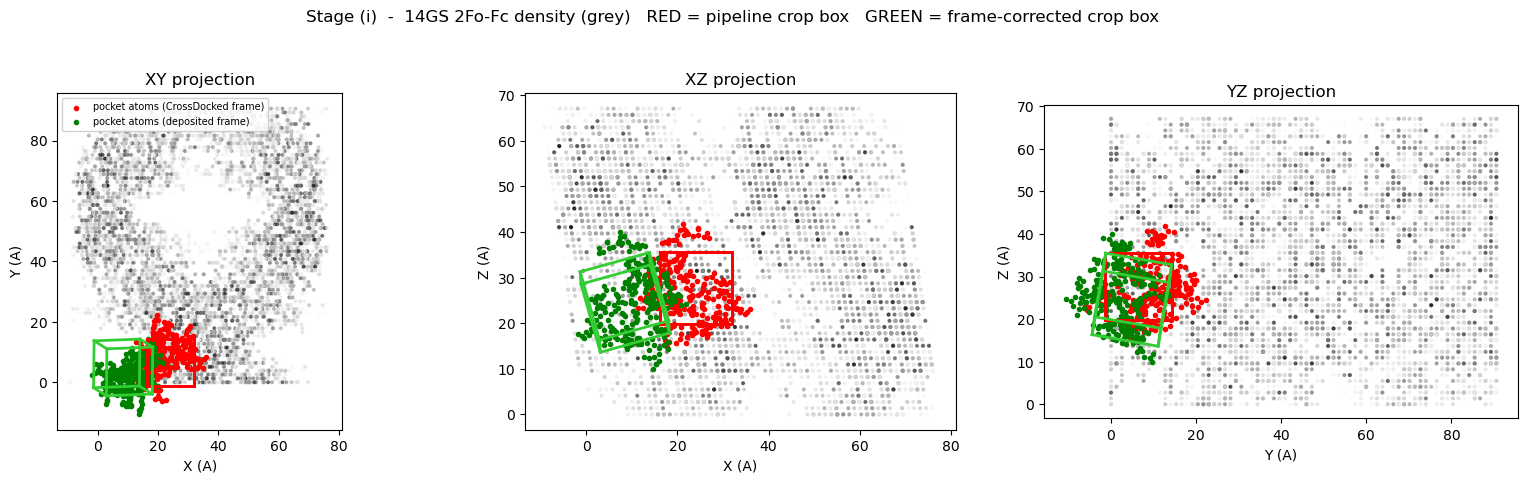

In [6]:
# --- Stage (i): density point cloud + both crop boxes, 3 projections + 3D ---
ii, jj, kk = np.where(map_z > 1.2)
val = map_z[ii, jj, kk]
cart = (np.stack([ii / NU, jj / NV, kk / NW], 1)) @ ORTH.T          # -> Cartesian A
rng = np.random.default_rng(0)
sel = rng.choice(len(cart), size=min(6000, len(cart)), replace=False)
cloud, cloud_v = cart[sel], val[sel]

EDGES = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
def corners(g):
    return g[np.ix_([0, -1], [0, -1], [0, -1])].reshape(8, 3)
box_pipe = corners(grid64)
box_corr = corners(cd_to_dep(grid64.reshape(-1, 3)).reshape(G, G, G, 3))

def draw_box(ax, C, color, a0, a1):
    for e in EDGES:
        p, q = C[e[0]], C[e[1]]
        ax.plot([p[a0], q[a0]], [p[a1], q[a1]], color=color, lw=2, zorder=5)

fig = plt.figure(figsize=(16, 4.6))
for n, (a0, a1, l0, l1) in enumerate([(0,1,"X","Y"), (0,2,"X","Z"), (1,2,"Y","Z")]):
    ax = fig.add_subplot(1, 3, n + 1)
    ax.scatter(cloud[:, a0], cloud[:, a1], c=cloud_v, s=4, cmap="Greys",
               alpha=.45, vmax=4, zorder=1)
    draw_box(ax, box_pipe, "red", a0, a1)
    draw_box(ax, box_corr, "limegreen", a0, a1)
    ax.scatter(cd_poc[:, a0], cd_poc[:, a1], s=9, c="red", zorder=4,
               label="pocket atoms (CrossDocked frame)")
    ax.scatter(Q[:, a0], Q[:, a1], s=9, c="green", zorder=4,
               label="pocket atoms (deposited frame)")
    ax.set_xlabel(f"{l0} (A)"); ax.set_ylabel(f"{l1} (A)")
    ax.set_title(f"{l0}{l1} projection"); ax.set_aspect("equal")
    if n == 0:
        ax.legend(fontsize=7, loc="upper left", framealpha=.9)
fig.suptitle("Stage (i)  -  14GS 2Fo-Fc density (grey)   "
             "RED = pipeline crop box   GREEN = frame-corrected crop box", y=1.04)
fig.tight_layout()
fig.savefig(FIGDIR / "01b_stage1_crop_region.png", dpi=110, bbox_inches="tight")
plt.show()

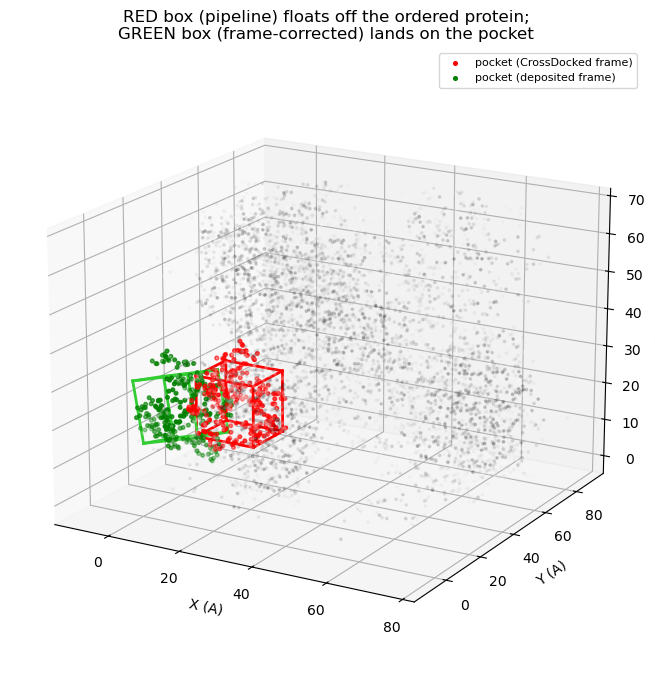

In [7]:
# --- Stage (i): 3D view ---
fig = plt.figure(figsize=(8.5, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(cloud[:, 0], cloud[:, 1], cloud[:, 2], c=cloud_v, s=3,
           cmap="Greys", alpha=.18, vmax=4)
for e in EDGES:
    for C, col in [(box_pipe, "red"), (box_corr, "limegreen")]:
        p, q = C[e[0]], C[e[1]]
        ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]], color=col, lw=2)
ax.scatter(*cd_poc.T, s=7, c="red",   label="pocket (CrossDocked frame)")
ax.scatter(*Q.T,      s=7, c="green", label="pocket (deposited frame)")
ax.set_xlabel("X (A)"); ax.set_ylabel("Y (A)"); ax.set_zlabel("Z (A)")
ax.set_title("RED box (pipeline) floats off the ordered protein;\n"
             "GREEN box (frame-corrected) lands on the pocket")
ax.legend(fontsize=8); ax.view_init(elev=18, azim=-60)
fig.tight_layout()
fig.savefig(FIGDIR / "01b_stage1_3d.png", dpi=110, bbox_inches="tight")
plt.show()

## Stage (ii) — cropped density at native sampling

The density inside the 16 Å box, sampled on a coarse grid at the map's **native ~1.3 Å**
spacing (no upsampling yet). The pipeline crop is featureless; the frame-corrected crop
shows the blocky protein density of the real pocket.


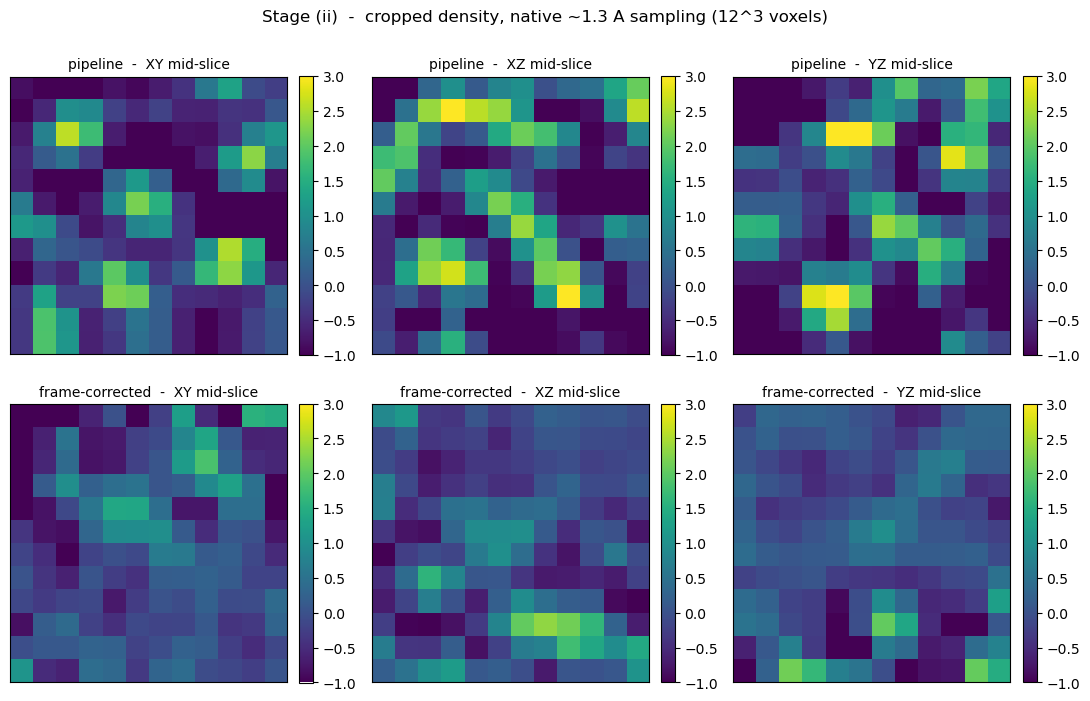

In [8]:
# --- Stage (ii): native-resolution crops, central slices ---
def show_slices(rows, suptitle, fname, vmin=-1, vmax=3):
    fig, axes = plt.subplots(len(rows), 3, figsize=(11, 3.5 * len(rows)))
    axes = np.atleast_2d(axes)
    for r, (vol, title) in enumerate(rows):
        c = vol.shape[0] // 2
        for cc, (plane, sl) in enumerate(
                [("XY", vol[:, :, c]), ("XZ", vol[:, c, :]), ("YZ", vol[c, :, :])]):
            ax = axes[r, cc]
            im = ax.imshow(sl.T, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
            ax.set_title(f"{title}  -  {plane} mid-slice", fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
            plt.colorbar(im, ax=ax, fraction=.046, pad=.04)
    fig.suptitle(suptitle, y=1.0, fontsize=12)
    fig.tight_layout()
    fig.savefig(fname, dpi=110, bbox_inches="tight")
    plt.show()

show_slices([(nat_buggy, "pipeline"), (nat_corrected, "frame-corrected")],
            f"Stage (ii)  -  cropped density, native ~{NATIVE:.1f} A sampling ({n_nat}^3 voxels)",
            FIGDIR / "01b_stage2_native_crop.png")

## Stage (iii) — interpolated density (64³ @ 0.25 Å)

Trilinear interpolation onto the VoxBind grid — this 64³ tensor is the x-ray channel fed
to the model. The interpolation maths is correct (the pipeline crop here equals the
on-disk `.npy`, verified above); it is simply interpolating the wrong region.

> The dataset additionally applies `normalize_crop` (local ±3 σ clip + z-score) at load
> time; shown here is the stored, globally z-scored crop.


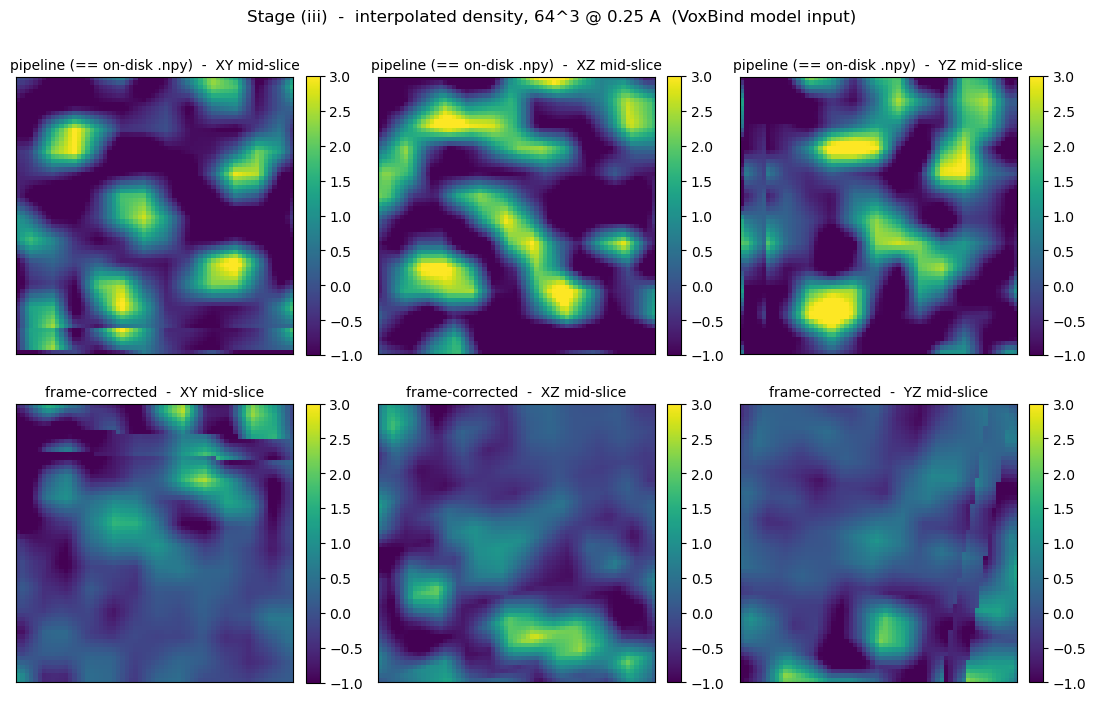

In [9]:
# --- Stage (iii): interpolated 64^3 crops, central slices ---
show_slices([(crop_buggy, "pipeline (== on-disk .npy)"), (crop_corrected, "frame-corrected")],
            "Stage (iii)  -  interpolated density, 64^3 @ 0.25 A  (VoxBind model input)",
            FIGDIR / "01b_stage3_interp_crop.png")

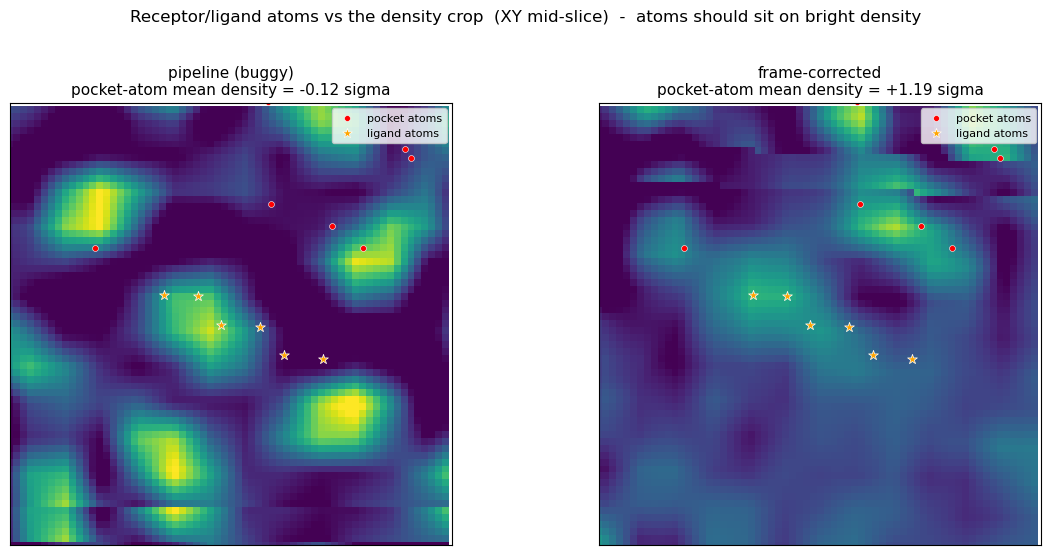

In [10]:
# --- Stage (iii): receptor/ligand atoms overlaid on the crop they are supposed to match ---
def to_vox(xyz):
    return (np.asarray(xyz) - cd_centroid) / RES + G / 2

vp, vl = to_vox(cd_poc), to_vox(cd_lig)
k0 = G // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, (crop, title) in zip(axes, [(crop_buggy, "pipeline (buggy)"),
                                     (crop_corrected, "frame-corrected")]):
    inbox = ((to_vox(cd_poc) >= 0) & (to_vox(cd_poc) <= G - 1)).all(1)
    zc = scipy.ndimage.map_coordinates(crop, to_vox(cd_poc)[inbox].T,
                                       order=1, mode="nearest").mean()
    ax.imshow(crop[:, :, k0].T, origin="lower", cmap="viridis", vmin=-1, vmax=3)
    near_p = np.abs(vp[:, 2] - k0) < 3
    near_l = np.abs(vl[:, 2] - k0) < 3
    ax.scatter(vp[near_p, 0], vp[near_p, 1], s=18, c="red", ec="white", lw=.4,
               label="pocket atoms")
    ax.scatter(vl[near_l, 0], vl[near_l, 1], s=55, marker="*", c="orange",
               ec="white", lw=.5, label="ligand atoms")
    ax.set_title(f"{title}\npocket-atom mean density = {zc:+.2f} sigma", fontsize=11)
    ax.set_xlim(0, G); ax.set_ylim(0, G); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Receptor/ligand atoms vs the density crop  (XY mid-slice)  -  "
             "atoms should sit on bright density", y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR / "01b_stage3_atom_overlay.png", dpi=110, bbox_inches="tight")
plt.show()

## Diagnostics — how bad, and how widespread

**Left** — mean 2Fo-Fc density (σ units) at the 255 matched receptor atoms, sampled in the
14GS map at: the pipeline's CrossDocked coords, the deposited coords, the Kabsch-corrected
coords, and random points in the box. Well-ordered protein atoms must sit on strong
positive density — the pipeline value is at the random-noise floor.

**Right** — the same test repeated for all **92 test-split crops** (each crop sampled at
its own pocket atoms). The distribution is bimodal: a crop is either correctly aligned
(> 1 σ) or misaligned (≈ 0 σ).


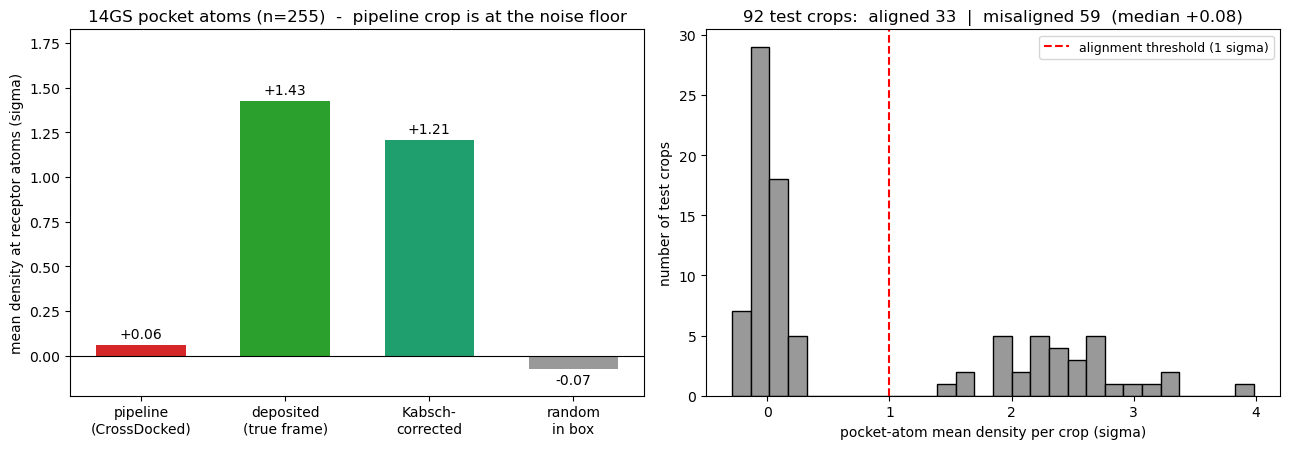

14GS pocket atoms : pipeline +0.059 sigma   corrected +1.206 sigma   deposited +1.426 sigma
test split        : 33/92 crops aligned (>1 sigma), 59/92 misaligned


In [11]:
# --- diagnostics ---
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.6))

# left: density at the 255 matched atoms, four placements
rand = cd_centroid + rng.uniform(-8, 8, size=(4000, 3))
bars = {
    "pipeline\n(CrossDocked)": sample_cart(P).mean(),
    "deposited\n(true frame)": sample_cart(Q).mean(),
    "Kabsch-\ncorrected":      sample_cart(cd_to_dep(P)).mean(),
    "random\nin box":          sample_cart(rand).mean(),
}
cols = ["#d62728", "#2ca02c", "#1f9e6e", "#999999"]
b = axL.bar(list(bars), list(bars.values()), color=cols, width=.62)
axL.bar_label(b, fmt="%+.2f", padding=3, fontsize=10)
axL.axhline(0, color="k", lw=.8)
axL.set_ylabel("mean density at receptor atoms (sigma)")
axL.set_title(f"14GS pocket atoms (n={len(P)})  -  pipeline crop is at the noise floor")
axL.set_ylim(min(0, min(bars.values())) - 0.15, max(bars.values()) + 0.4)

# right: 92-test-crop scan from the on-disk crops
avail = np.load(DATA / "xray_crops" / "test_available.npy")
pmeans = []
for i in range(len(data)):
    if not avail[i]:
        continue
    crop = np.load(DATA / "xray_crops" / "test" / f"{i:06d}.npy").astype(np.float32)
    p_, l_ = data[i]
    poc = p_["coords"][p_["atoms_channel"] < 4].float().numpy()
    cen = l_["coords"][l_["atoms_channel"] < 7].float().mean(0).numpy()
    v = (poc - cen) / RES + G / 2
    v = v[((v >= 0) & (v <= G - 1)).all(1)]
    if len(v):
        pmeans.append(scipy.ndimage.map_coordinates(crop, v.T, order=1, mode="nearest").mean())
pmeans = np.array(pmeans)
n_ok = int((pmeans > 1.0).sum())
axR.hist(pmeans, bins=28, color="#999999", edgecolor="k", lw=.5)
axR.axvline(1.0, color="red", ls="--", lw=1.5, label="alignment threshold (1 sigma)")
axR.set_xlabel("pocket-atom mean density per crop (sigma)")
axR.set_ylabel("number of test crops")
axR.set_title(f"92 test crops:  aligned {n_ok}  |  misaligned {len(pmeans)-n_ok}  "
              f"(median {np.median(pmeans):+.2f})")
axR.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGDIR / "01b_diagnostics.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"14GS pocket atoms : pipeline {sample_cart(P).mean():+.3f} sigma   "
      f"corrected {sample_cart(cd_to_dep(P)).mean():+.3f} sigma   "
      f"deposited {sample_cart(Q).mean():+.3f} sigma")
print(f"test split        : {n_ok}/{len(pmeans)} crops aligned (>1 sigma), "
      f"{len(pmeans)-n_ok}/{len(pmeans)} misaligned")

## Conclusion

| Pipeline check | Verdict |
|----------------|---------|
| Download by protein type (PDBe EDS, PDB-ID parsing, map content) | **correct** |
| Crop / align to CrossDocked2020 | **broken** — crops in the CrossDocked reference frame, not the map's deposited frame |
| Interpolation to 64³ @ 0.25 Å | **mechanically correct** (matches on-disk `.npy`), but applied to the wrong region |

**Root cause.** CrossDocked2020 superposes each pocket's receptors onto a shared reference;
that frame differs from each structure's own crystallographic frame — for 14GS by a
**179° rotation + 40 Å translation** (a C2 symmetry operation). `_crop_density` samples the
PDBe-EDS map at CrossDocked-frame coordinates, so the x-ray density channel is spatially
decorrelated from the receptor/ligand for **~64 %** of structures.

**Consequence for the 10k density A/B.** The `density` arm is trained & sampled on density
that is correctly aligned only ~1/3 of the time; `density ≈ noise ≈ baseline` is expected,
so the experiment cannot reveal a true density benefit as-is.

**Fix (next step).** Per structure, recover the rigid transform CrossDocked-frame →
deposited-frame (residue-matched Kabsch vs the deposited PDB, as done here) and crop the
map along the transformed grid. Verified above to restore receptor-atom density from
**+0.06 σ → +1.21 σ**.
